## Examples: Clustering and geospatial analysis

#### In this notebook, we'll use geopandas to plot geospatial data and create multidimensional plots by adjusting size and color.

### **Learning Objectives**
#### By the end of this notebook, you should be able to:
#### - Create multidimensional plots by adjusting size and color.
#### - Use geopandas to plot geospatial data

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/acs2015_county_data.csv', encoding='utf-8').dropna()
df.head()

,CensusId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001,Alabama,Autauga,55221,26745,28476,2.6,75.8,18.5,0.4,...,0.5,1.3,1.8,26.5,23986,73.6,20.9,5.5,0.0,7.6
1,1003,Alabama,Baldwin,195121,95314,99807,4.5,83.1,9.5,0.6,...,1.0,1.4,3.9,26.4,85953,81.5,12.3,5.8,0.4,7.5
2,1005,Alabama,Barbour,26932,14497,12435,4.6,46.2,46.7,0.2,...,1.8,1.5,1.6,24.1,8597,71.8,20.8,7.3,0.1,17.6
3,1007,Alabama,Bibb,22604,12073,10531,2.2,74.5,21.4,0.4,...,0.6,1.5,0.7,28.8,8294,76.8,16.1,6.7,0.4,8.3
4,1009,Alabama,Blount,57710,28512,29198,8.6,87.9,1.5,0.3,...,0.9,0.4,2.3,34.9,22189,82.0,13.5,4.2,0.4,7.7


In [3]:
labels = ['CensusId', 'State', 'County']
features = [col for col in df.columns if col not in labels]

scaler = StandardScaler()
df[features] = df[features].astype('float64')
X = scaler.fit_transform(df[features])

In [4]:
hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward',
    metric='euclidean'
).fit(X)

df['cluster'] = hc.labels_ + 1
df['cluster'] = df['cluster'].astype('int64')

In [5]:
df.head()

,CensusId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,cluster
0,1001,Alabama,Autauga,55221.0,26745.0,28476.0,2.6,75.8,18.5,0.4,...,1.3,1.8,26.5,23986.0,73.6,20.9,5.5,0.0,7.6,2
1,1003,Alabama,Baldwin,195121.0,95314.0,99807.0,4.5,83.1,9.5,0.6,...,1.4,3.9,26.4,85953.0,81.5,12.3,5.8,0.4,7.5,2
2,1005,Alabama,Barbour,26932.0,14497.0,12435.0,4.6,46.2,46.7,0.2,...,1.5,1.6,24.1,8597.0,71.8,20.8,7.3,0.1,17.6,1
3,1007,Alabama,Bibb,22604.0,12073.0,10531.0,2.2,74.5,21.4,0.4,...,1.5,0.7,28.8,8294.0,76.8,16.1,6.7,0.4,8.3,2
4,1009,Alabama,Blount,57710.0,28512.0,29198.0,8.6,87.9,1.5,0.3,...,0.4,2.3,34.9,22189.0,82.0,13.5,4.2,0.4,7.7,2


### **Multidimensional Plotting**

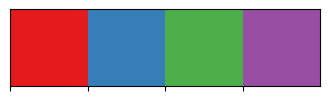

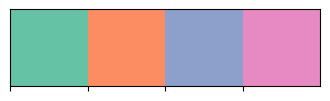

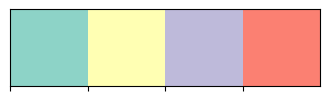

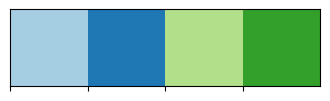

In [6]:
sns.palplot(sns.color_palette("Set1", n_colors=4))
sns.palplot(sns.color_palette("Set2", n_colors=4))
sns.palplot(sns.color_palette("Set3", n_colors=4))
sns.palplot(sns.color_palette("Paired", n_colors=4))

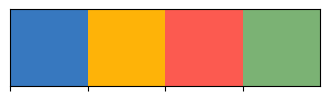

In [7]:
colors = ['windows blue', 'amber', 'coral', 'faded green']
sns.palplot(sns.xkcd_palette(colors))

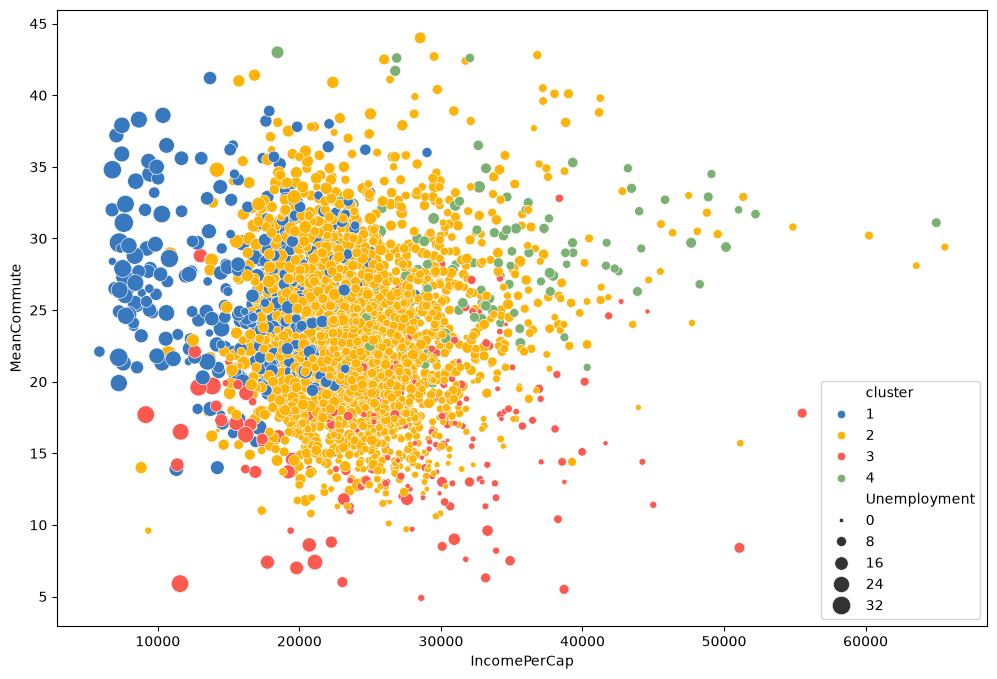

In [8]:
cmap = sns.xkcd_palette(colors)
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(
    x='IncomePerCap',
    y='MeanCommute',
    hue='cluster',
    size='Unemployment',
    palette=cmap,
    sizes=(10, 200),
    data=df
)

plt.show()

### Quick Introduction to geospatial data analysis

In [9]:
gdf = gpd.read_file('https://raw.githubusercontent.com/python-visualization/folium/master/tests/us-counties.json')

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


In [10]:
gdf.head()

,id,name,geometry
0,1001,Autauga,"POLYGON ((-86.41179 32.70634, -86.41179 32.410..."
1,1003,Baldwin,"POLYGON ((-87.76459 31.29877, -87.61671 31.244..."
2,1005,Barbour,"POLYGON ((-85.35474 32.14769, -85.0535 32.0655..."
3,1007,Bibb,"POLYGON ((-87.06354 33.24856, -87.0252 33.2485..."
4,1009,Blount,"POLYGON ((-86.48846 34.26179, -86.4556 34.2617..."


In [11]:
gdf['id'] = gdf['id'].astype('int64')
df = pd.merge(left=df, right=gdf, how='inner', left_on='CensusId', right_on='id')
del df['id']
del df['name']

# convert to a GeoDataFrame, specifying which column we wish to use for the geometry info
# df = gpd.GeoDataFrame(df, geometry='geometry')
# df.head(3)
df = gpd.GeoDataFrame(df, geometry='geometry')
df.head(3)

,CensusId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,cluster,geometry
0,1001,Alabama,Autauga,55221.0,26745.0,28476.0,2.6,75.8,18.5,0.4,...,1.8,26.5,23986.0,73.6,20.9,5.5,0.0,7.6,2,"POLYGON ((-86.41179 32.70634, -86.41179 32.410..."
1,1003,Alabama,Baldwin,195121.0,95314.0,99807.0,4.5,83.1,9.5,0.6,...,3.9,26.4,85953.0,81.5,12.3,5.8,0.4,7.5,2,"POLYGON ((-87.76459 31.29877, -87.61671 31.244..."
2,1005,Alabama,Barbour,26932.0,14497.0,12435.0,4.6,46.2,46.7,0.2,...,1.6,24.1,8597.0,71.8,20.8,7.3,0.1,17.6,1,"POLYGON ((-85.35474 32.14769, -85.0535 32.0655..."


In [15]:
df.dtypes

CensusId              int64
State                   str
County                  str
TotalPop            float64
Men                 float64
Women               float64
Hispanic            float64
White               float64
Black               float64
Native              float64
Asian               float64
Pacific             float64
Citizen             float64
Income              float64
IncomeErr           float64
IncomePerCap        float64
IncomePerCapErr     float64
Poverty             float64
ChildPoverty        float64
Professional        float64
Service             float64
Office              float64
Construction        float64
Production          float64
Drive               float64
Carpool             float64
Transit             float64
Walk                float64
OtherTransp         float64
WorkAtHome          float64
MeanCommute         float64
Employed            float64
PrivateWork         float64
PublicWork          float64
SelfEmployed        float64
FamilyWork          

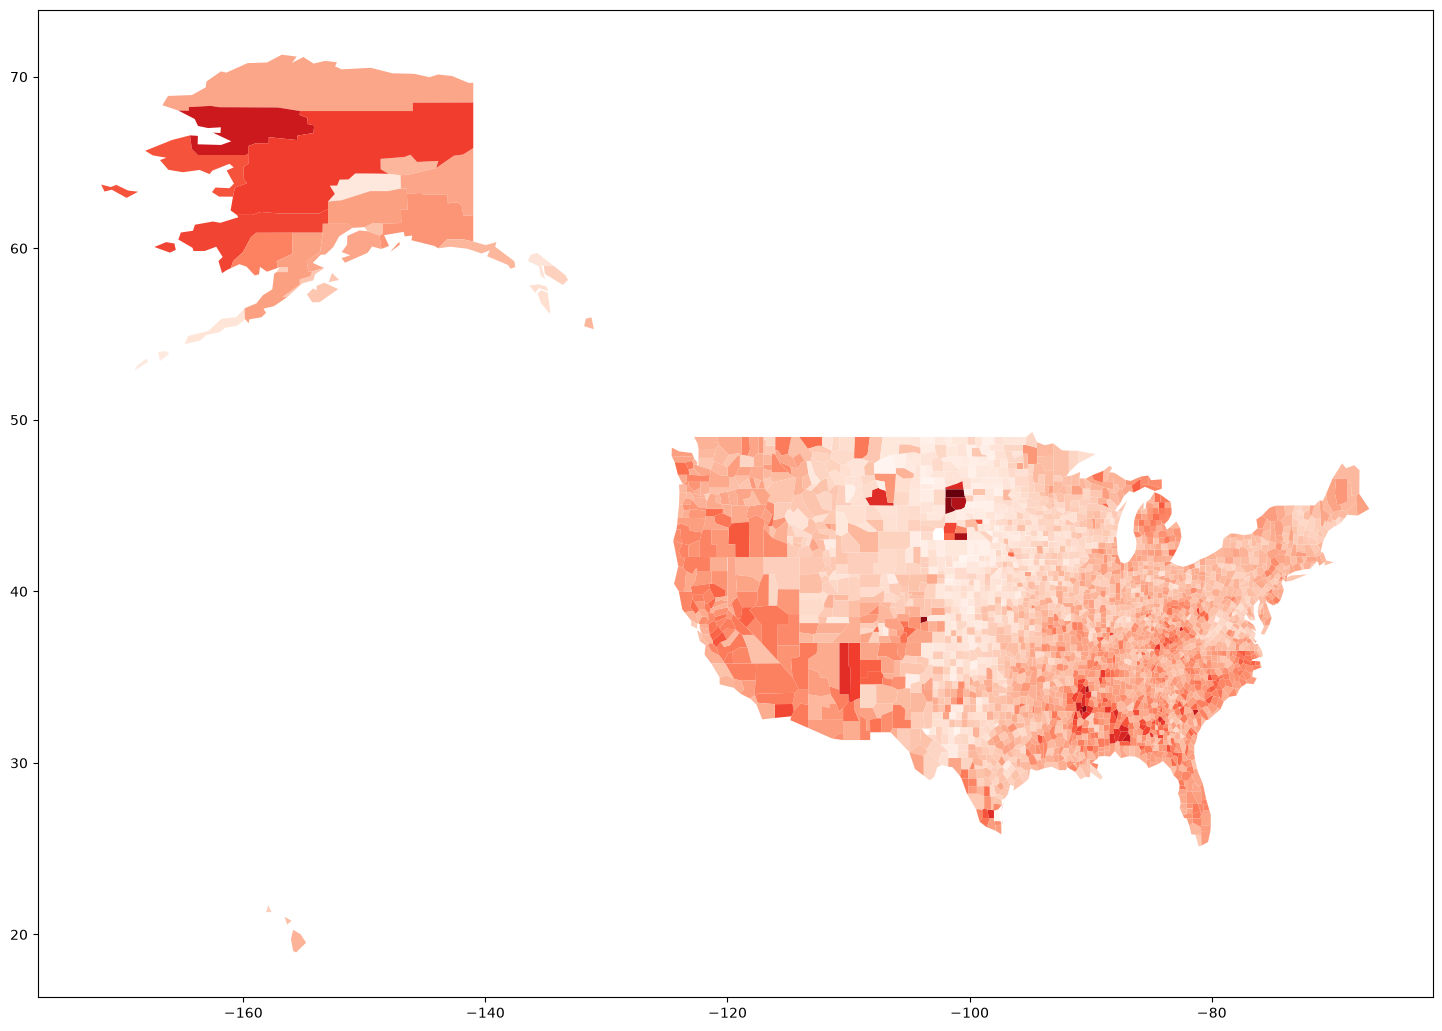

In [13]:
df.plot(
    column='Unemployment',
    cmap='Reds',
    figsize=(18, 16)
)

plt.show()

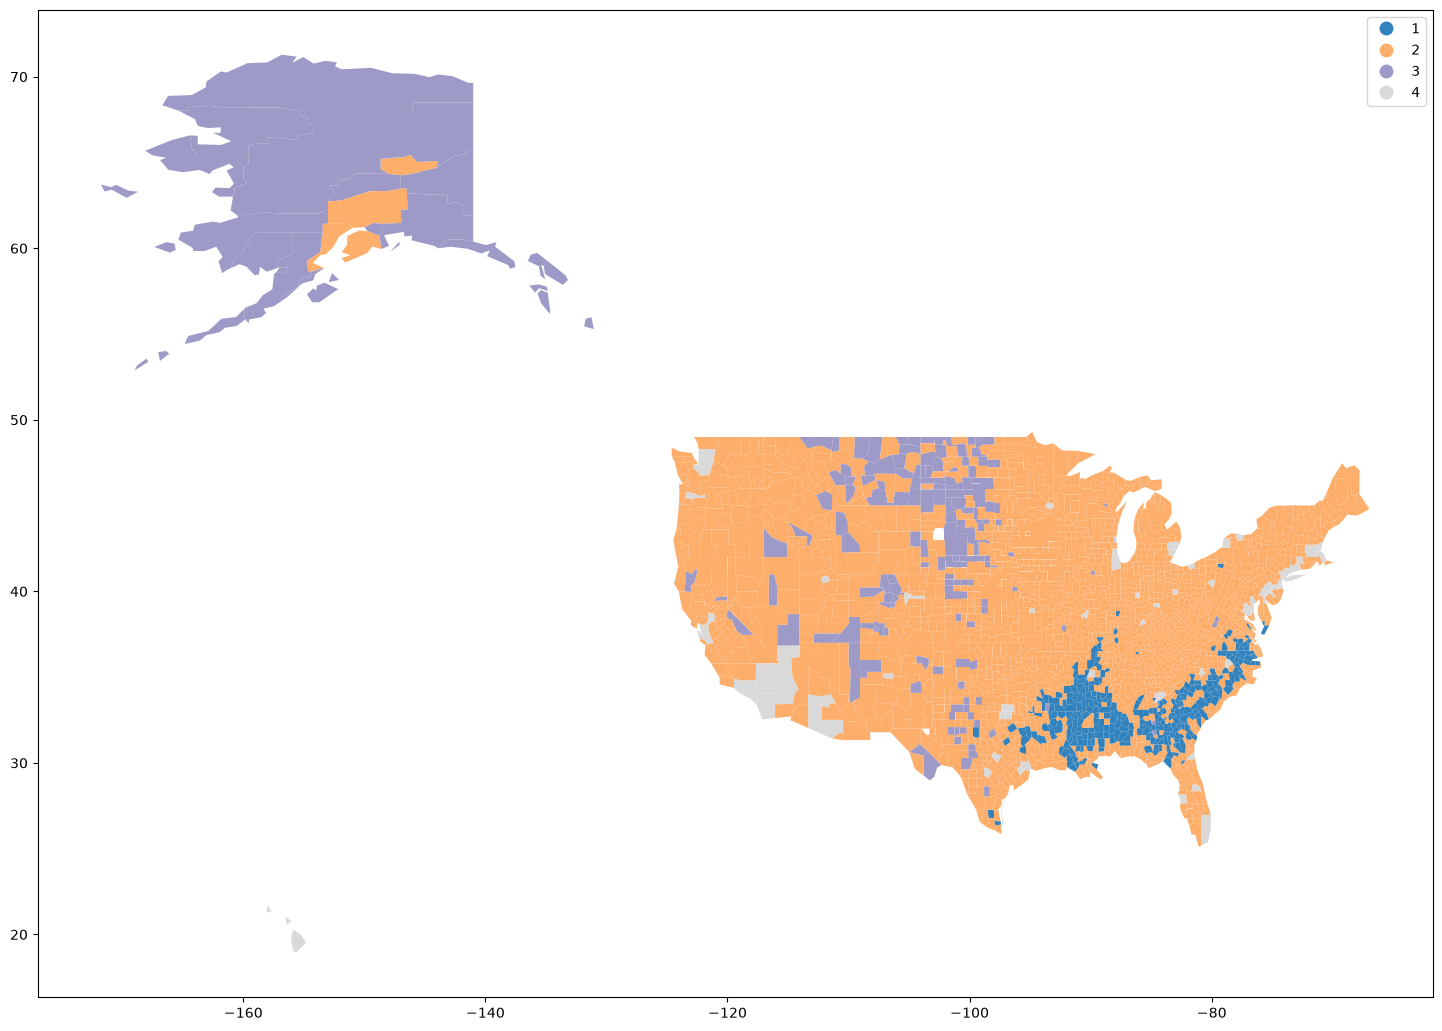

In [14]:
df.plot(
    column='cluster',
    cmap='tab20c',
    figsize=(18, 16),
    categorical=True,
    legend=True
)

plt.show()